**Simple Neural Network Test**

1. Generate data

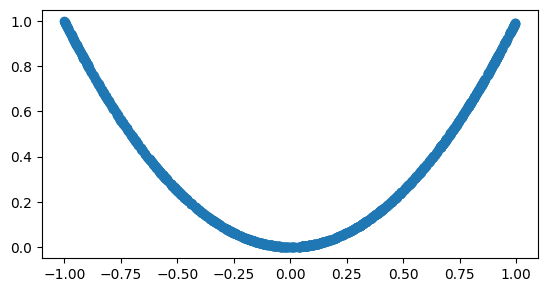

(tensor([[ 0.0909],
         [-0.5932],
         [ 0.0736],
         [ 0.3986],
         [ 0.4053]]),
 tensor([0.0083, 0.3519, 0.0054, 0.1589, 0.1643]))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

nSamples = 1000

# random numbers between 0 and 1
input = np.random.rand(nSamples)
X = 2*input-1

# output data
y = X**2

plt.figure()
plt.scatter(X,y)
plt.axis("scaled")
plt.show()

# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
X = X[:,None]
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]
#X.shape

torch.Size([1000])

In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [4]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [26]:
# Build model with non-linear activation function
from torch import nn
class Model1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=1, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model = Model1().to(device)
print(model)

Model1(
  (layer_1): Linear(in_features=1, out_features=20, bias=True)
  (layer_2): Linear(in_features=20, out_features=20, bias=True)
  (layer_3): Linear(in_features=20, out_features=1, bias=True)
  (relu): ReLU()
)


In [27]:
# Setup loss and optimizer 
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [28]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    diff = y_true - y_pred
    acc = torch.norm(diff) 
    return acc

In [38]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    model.train()
    
    y_logits = model(X_train).flatten()
    
    
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # 
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model(X_test)
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

/home/beni/miniconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([200])) that is different to the input size (torch.Size([200, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 0 | Loss: 0.09032 | Test Loss: 0.10159
Epoch: 100 | Loss: 0.00006 | Test Loss: 0.20322
Epoch: 200 | Loss: 0.00003 | Test Loss: 0.20295
Epoch: 300 | Loss: 0.00003 | Test Loss: 0.20301
Epoch: 400 | Loss: 0.00002 | Test Loss: 0.20304
Epoch: 500 | Loss: 0.00002 | Test Loss: 0.20305
Epoch: 600 | Loss: 0.00002 | Test Loss: 0.20306
Epoch: 700 | Loss: 0.00002 | Test Loss: 0.20293
Epoch: 800 | Loss: 0.00002 | Test Loss: 0.20305
Epoch: 900 | Loss: 0.00002 | Test Loss: 0.20254


tensor([[0.4785],
        [0.0442],
        [0.2088],
        [0.9711],
        [0.6828]], device='cuda:0', grad_fn=<SliceBackward0>)
tensor([0.4859, 0.0407, 0.2068, 0.9798, 0.6804], device='cuda:0')


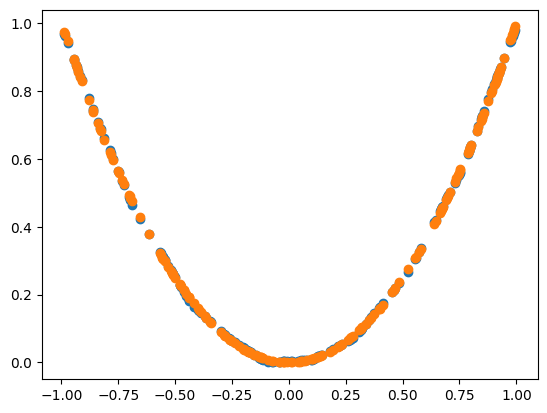

In [39]:
Res = model(X_test)
print(Res[:5])
print(y_test[:5])

plt.figure()
plt.scatter(X_test.cpu().numpy(),Res.detach().cpu().numpy())
plt.scatter(X_test.cpu().numpy(),y_test.cpu().numpy())
plt.show()